In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR, adfuller
from statsmodels.datasets import macrodata
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
data = macrodata.load_pandas().data
print("Dataset Head:")
data.head()

Dataset Head:


,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [3]:
from sklearn.preprocessing import MinMaxScaler

In [4]:
# Select relevant columns for VAR modeling: Real GDP, Real Consumption, Real Investment
df = data[["realgdp", "infl", "unemp"]]
# Assign proper column names and set the index using the cycle information
# The index is constructed using the period column of the macrodata (e.g., 1959Q1, 1959Q2)
df.columns = ['Real_GDP', 'Consumption', 'Investment']
df.index = pd.period_range(start='1959Q1', periods=len(df), freq='Q')
df.index = df.index.to_timestamp() 

# We use a recent subset of the data (last 100 quarters) for faster training
# df = df.iloc[-100:]

In [5]:
scaler = MinMaxScaler()
df_new = pd.DataFrame(scaler.fit_transform(df),columns=['Real_GDP', 'Consumption', 'Investment'])
df_new.index = df.index

In [6]:
df_new

,Real_GDP,Consumption,Investment
1959-01-01,0.000000,0.375481,0.328767
1959-04-01,0.006394,0.475438,0.232877
1959-07-01,0.006085,0.492525,0.260274
1959-10-01,0.006993,0.387014,0.301370
1960-01-01,0.012831,0.474156,0.246575
...,...,...,...
2008-07-01,0.991530,0.240496,0.356164
2008-10-01,0.974465,0.000000,0.479452
2009-01-01,0.954240,0.415634,0.643836
2009-04-01,0.952007,0.519436,0.794521


In [7]:
# Separate data into training and testing sets
TRAIN_SIZE = 190
train_data = df_new[:TRAIN_SIZE]
test_data = df_new[TRAIN_SIZE:]
print(f"Total Observations: {len(data)} (Quarterly)")
print(f"Training Observations: {len(train_data)}")
print(f"Testing Observations (Forecast Horizon): {len(test_data)}")

Total Observations: 203 (Quarterly)
Training Observations: 190
Testing Observations (Forecast Horizon): 13


In [8]:
# Helper function to check for stationarity using the ADF test
def check_stationarity(series, name):
    """Performs Augmented Dickey-Fuller test on a series."""
    result = adfuller(series.dropna())
    print(f'\n--- ADF Test for {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    
    # Critical value check
    is_stationary = result[1] <= 0.05
    print(f"Conclusion: {'Stationary' if is_stationary else 'Non-Stationary (Need to Difference)'}")
    return is_stationary

# Check initial data stationarity (expected to be non-stationary)
for col in train_data.columns:
    check_stationarity(train_data[col], col)

# Differencing the data to achieve stationarity (First Difference)
# We use the log difference (rate of change) which is common for macroeconomic data
train_data_diff = train_data.diff().dropna()
print("\n--- Log Differencing Applied ---")

# Re-check stationarity on differenced data
for col in train_data_diff.columns:
    check_stationarity(train_data_diff[col], f'{col}_Diff')


--- ADF Test for Real_GDP ---
ADF Statistic: 2.7743
p-value: 1.0000
Conclusion: Non-Stationary (Need to Difference)

--- ADF Test for Consumption ---
ADF Statistic: -2.4258
p-value: 0.1346
Conclusion: Non-Stationary (Need to Difference)

--- ADF Test for Investment ---
ADF Statistic: -2.4174
p-value: 0.1369
Conclusion: Non-Stationary (Need to Difference)

--- Log Differencing Applied ---

--- ADF Test for Real_GDP_Diff ---
ADF Statistic: -6.0118
p-value: 0.0000
Conclusion: Stationary

--- ADF Test for Consumption_Diff ---
ADF Statistic: -5.7316
p-value: 0.0000
Conclusion: Stationary

--- ADF Test for Investment_Diff ---
ADF Statistic: -4.5253
p-value: 0.0002
Conclusion: Stationary


In [9]:
# --- 2. VAR Model Optimization (Lag Selection) ---

print("\n--- 2. VAR Model Optimization (Lag Selection) ---")
# The VAR model must be fitted on stationary data
model = VAR(train_data_diff)

# Test lags up to 10 and select the best using Information Criteria
# BIC is often preferred for more parsimonious (simpler) models.
lag_results = model.select_order(maxlags=10)
print(lag_results.summary())

optimal_lag = lag_results.bic # Use BIC criterion to select the lag order
print(f"\nOptimal Lag (chosen by BIC): {optimal_lag}")


--- 2. VAR Model Optimization (Lag Selection) ---
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -21.78      -21.72   3.488e-10      -21.75
1       -22.60      -22.39   1.531e-10      -22.51
2      -22.86*     -22.48*  1.183e-10*     -22.71*
3       -22.81      -22.27   1.243e-10      -22.59
4       -22.82      -22.12   1.231e-10      -22.54
5       -22.77      -21.92   1.293e-10      -22.42
6       -22.74      -21.72   1.339e-10      -22.32
7       -22.71      -21.53   1.379e-10      -22.23
8       -22.69      -21.36   1.405e-10      -22.15
9       -22.67      -21.18   1.437e-10      -22.06
10      -22.65      -20.99   1.474e-10      -21.98
--------------------------------------------------

Optimal Lag (chosen by BIC): 2


In [10]:
# --- 3. Model Fitting and Forecasting Setup ---

print("\n--- 3. Model Fitting ---")
# Fit the VAR model using the determined optimal lag
results = model.fit(optimal_lag)
print(results.summary())


# Preparation for multi-step forecasting
# The forecast function requires the last 'p' (optimal_lag) observations 
# of the differenced training data as input.
input_data = train_data_diff.values[-optimal_lag:]
forecast_steps = len(test_data)
print(f"\nForecasting {forecast_steps} steps ahead...")

# Generate the forecast on the DIFFERENCED scale
forecast_diff = results.forecast(input_data, steps=forecast_steps)
forecast_diff_df = pd.DataFrame(forecast_diff, 
                                index=test_data.index, 
                                columns=test_data.columns)



--- 3. Model Fitting ---
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 04, Oct, 2025
Time:                     13:55:11
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -22.5114
Nobs:                     187.000    HQIC:                  -22.7273
Log likelihood:           1363.72    FPE:                1.16378e-10
AIC:                     -22.8743    Det(Omega_mle):     1.04229e-10
--------------------------------------------------------------------
Results for equation Real_GDP
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.002572         0.000644            3.993           0.000
L1.Real_GDP            0.162326         0.082109            1.977           0.048
L1.Consumption        -0.00

In [11]:
# --- 4. Inverse Transformation (Reverting to Original Scale) ---

# The forecast is on the log-differenced scale (rate of change), 
# we must integrate it back to the original level scale.

# 1. Get the last known log-level value from the training data
last_train_log_values = train_data.iloc[-1].values

# 2. Revert the forecast to log-levels using cumulative sum
forecast_log_levels = np.cumsum(forecast_diff, axis=0)
forecast_log_levels += last_train_log_values

# 3. Exponentiate to get the forecast back to the original level scale
forecast_levels = forecast_log_levels

forecast_levels_df = pd.DataFrame(forecast_levels, 
                                  index=test_data.index, 
                                  columns=test_data.columns)

In [12]:
# --- 5. Evaluation (Metrics) ---

print("\n--- 5. Forecast Evaluation (Test Set) ---")
# Actual values for the test period
actual_levels = test_data.values

# Calculate common evaluation metrics
metrics = {}
for i, col in enumerate(test_data.columns):
    actual = actual_levels[:, i]
    predicted = forecast_levels[:, i]
    
    # Root Mean Squared Error (RMSE)
    rmse = mean_squared_error(actual, predicted, squared=False)
    
    # Mean Absolute Error (MAE)
    mae = mean_absolute_error(actual, predicted)
    
    metrics[col] = {'RMSE': rmse, 'MAE': mae}

metrics_df = pd.DataFrame(metrics).T
print(metrics_df.round(4))


--- 5. Forecast Evaluation (Test Set) ---
               RMSE     MAE
Real_GDP     0.0347  0.0221
Consumption  0.1812  0.1192
Investment   0.3178  0.2044


C:\Users\Sreekanth\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Sreekanth\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Sreekanth\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



--- 6. Visualization ---


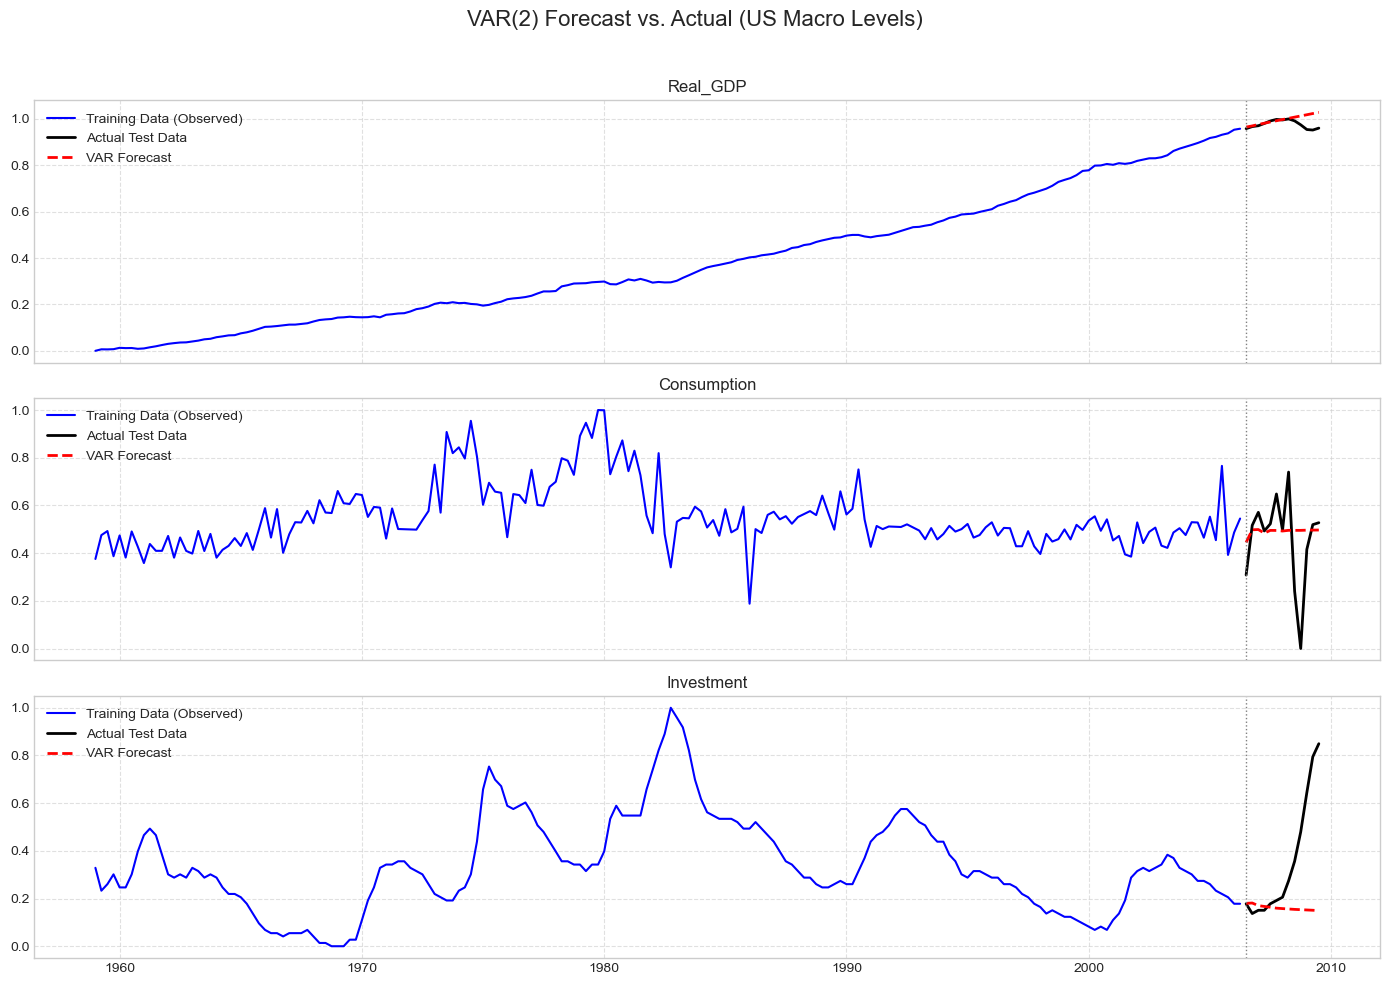


Code Execution Complete. Check plots for visualization.


In [13]:
# --- 6. Visualization (Original Scale) ---

print("\n--- 6. Visualization ---")
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 10), sharex=True)
plt.suptitle(f"VAR({optimal_lag}) Forecast vs. Actual (US Macro Levels)", fontsize=16)

for i, col in enumerate(df.columns):
    ax = axes[i]
    
    # Plot training data
    ax.plot(train_data[col], label='Training Data (Observed)', color='blue', linewidth=1.5)
    
    # Plot actual test data
    ax.plot(test_data[col], label='Actual Test Data', color='black', linestyle='-', linewidth=2)
    
    # Plot forecast
    ax.plot(forecast_levels_df[col], label='VAR Forecast', color='red', linestyle='--', linewidth=2)
    
    ax.set_title(col, fontsize=12)
    ax.legend(loc='upper left')
    ax.axvline(x=test_data.index[0], color='gray', linestyle=':', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\nCode Execution Complete. Check plots for visualization.")



--- 4. Model Diagnostics and Dynamic Analysis ---

--- 4.1 Residual Whiteness Test (Serial Correlation) ---
Adjusted Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         105.2          92.81   0.006 72
----------------------------------------


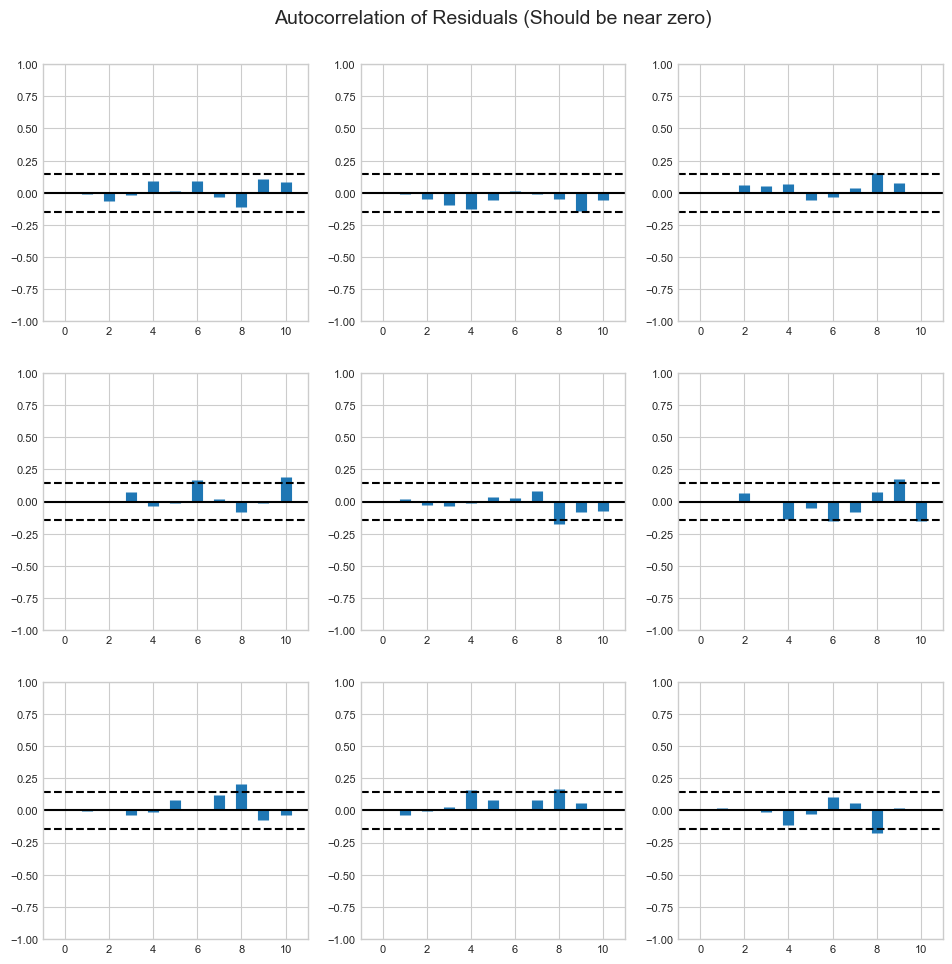

In [14]:
# --- 4. Model Diagnostics and Dynamic Analysis ---

print("\n--- 4. Model Diagnostics and Dynamic Analysis ---")

# --- 4.1 Check for Serial Correlation (Portmanteau Test) ---
# H0: No autocorrelation in the residuals (White Noise). We want p-value > 0.05.
print("\n--- 4.1 Residual Whiteness Test (Serial Correlation) ---")
# Use the Portmanteau test
serial_test = results.test_whiteness(nlags=10, adjusted=True)
# The test summary shows the p-value for the joint hypothesis across all lags
print(serial_test.summary())

# Plot the Autocorrelation Function (ACF) of residuals for visual inspection
results.plot_acorr()
plt.suptitle("Autocorrelation of Residuals (Should be near zero)", fontsize=14)
plt.show()

In [15]:
# --- 4.2 Check for Normality ---
# H0: Residuals are multivariate normally distributed
print("\n--- 4.2 Residual Normality Test (Skewness and Kurtosis) ---")
normality_test = results.test_normality()
print(normality_test.summary())


--- 4.2 Residual Normality Test (Skewness and Kurtosis) ---
normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         95.78          12.59   0.000  6
----------------------------------------



--- 4.3 Impulse Response Functions (IRF) ---


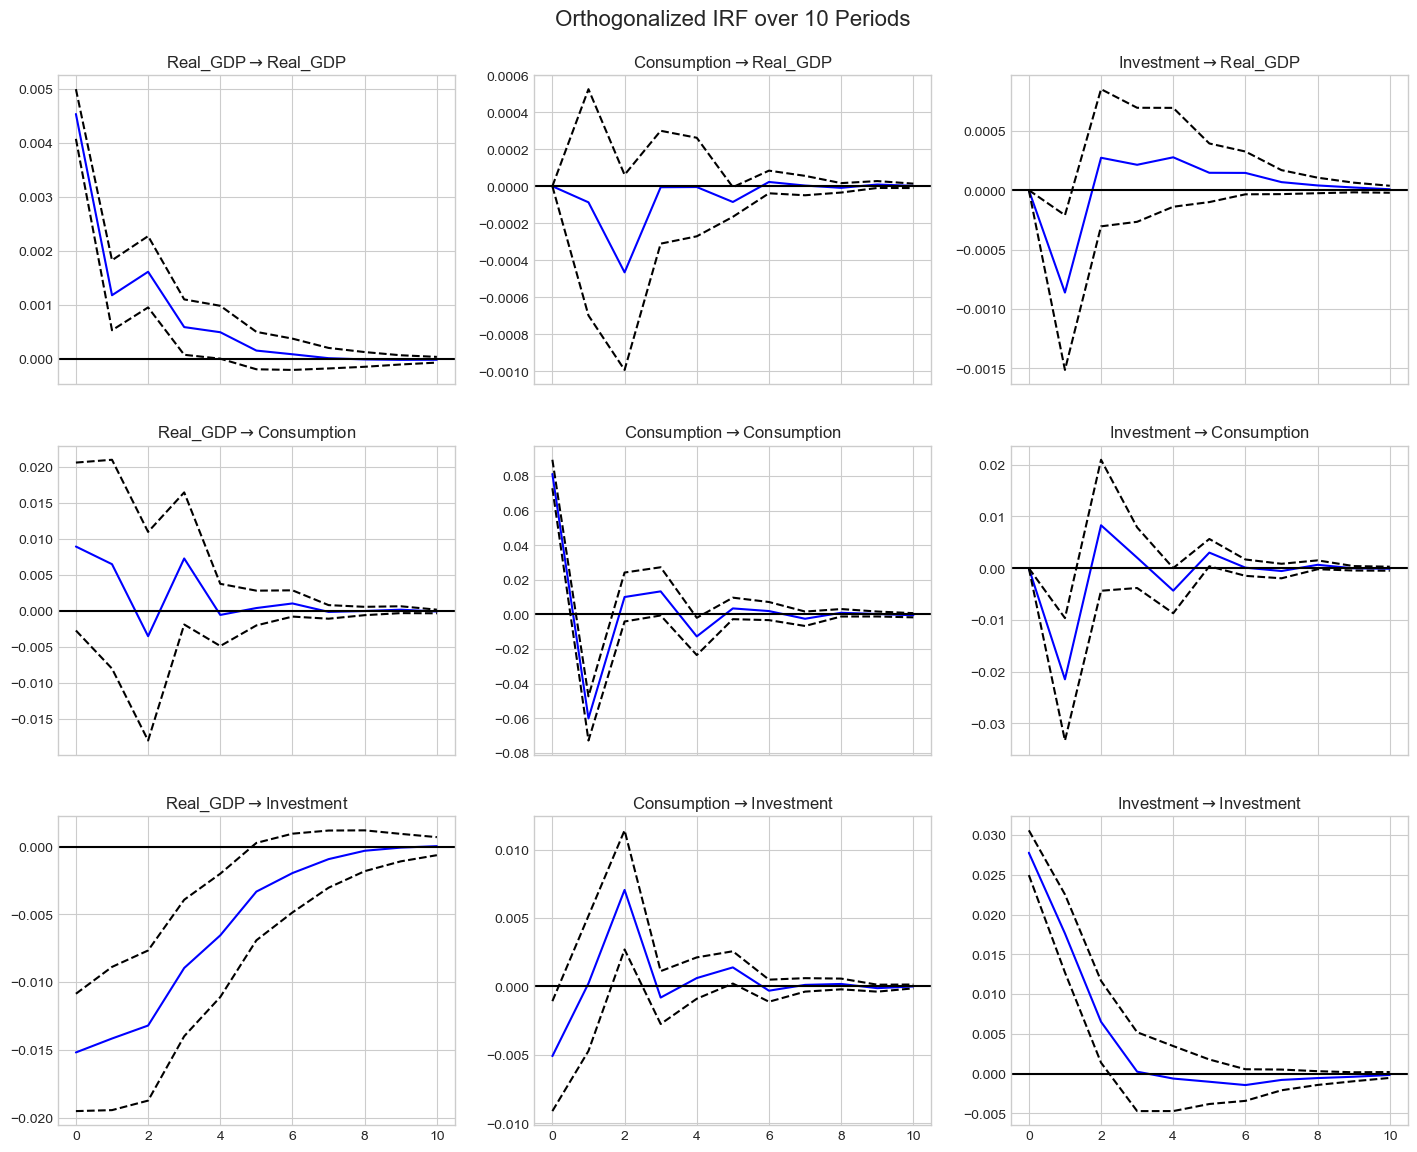

In [16]:
# --- 4.3 Impulse Response Functions (IRF) ---
# Traces the effect of a one-time shock in one variable on all others
print("\n--- 4.3 Impulse Response Functions (IRF) ---")
irf_periods = 10
irf = results.irf(periods=irf_periods)
# Plot orthogonalized IRF (using Cholesky decomposition)
# The ordering here (Real_GDP -> Consumption -> Investment) assumes GDP shocks hit 
# Consumption and Investment instantly, but Investment only affects the others with a lag.
irf.plot(orth=True, figsize=(15, 12))
plt.suptitle(f"Orthogonalized IRF over {irf_periods} Periods", fontsize=16)
plt.show()


--- 4.4 Forecast Error Variance Decomposition (FEVD) ---

FEVD Summary (Percentage Contribution of Shocks to Variance):
FEVD for Real_GDP
     Real_GDP  Consumption  Investment
0    1.000000     0.000000    0.000000
1    0.966874     0.000333    0.032793
2    0.959245     0.008764    0.031992
3    0.958105     0.008631    0.033264
4    0.955705     0.008526    0.035769
5    0.954707     0.008783    0.036510
6    0.953937     0.008794    0.037269
7    0.953772     0.008793    0.037436
8    0.953712     0.008795    0.037493
9    0.953691     0.008798    0.037511

FEVD for Consumption
     Real_GDP  Consumption  Investment
0    0.011940     0.988060    0.000000
1    0.011264     0.945917    0.042820
2    0.012217     0.939386    0.048397
3    0.016675     0.935572    0.047752
4    0.016440     0.934912    0.048648
5    0.016421     0.934224    0.049355
6    0.016504     0.934160    0.049335
7    0.016497     0.934170    0.049333
8    0.016495     0.934140    0.049365
9    0.016497     0.

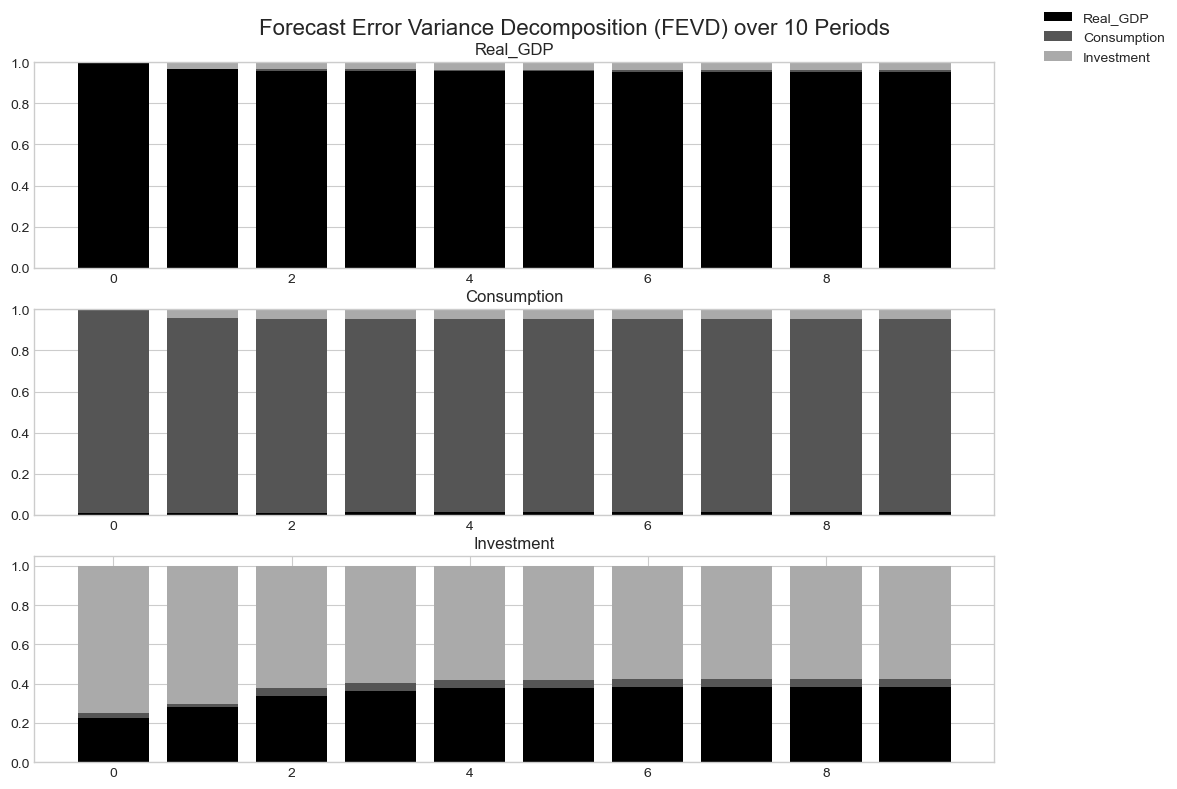

In [17]:
# --- 4.4 Forecast Error Variance Decomposition (FEVD) ---
# Quantifies the contribution of each shock to the forecast error variance
print("\n--- 4.4 Forecast Error Variance Decomposition (FEVD) ---")
fevd_periods = 10
fevd_results = results.fevd(fevd_periods)

# Print the FEVD summary table (percentage contributions)
print("\nFEVD Summary (Percentage Contribution of Shocks to Variance):")
print(fevd_results.summary())

# Plot the FEVD results
fevd_results.plot(figsize=(12, 8))
plt.suptitle(f"Forecast Error Variance Decomposition (FEVD) over {fevd_periods} Periods", fontsize=16)
plt.show()